In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob

import h5py

$\delta \ln Y = \ln Y - \langle\ln Y | M \rangle $
where $\langle\ln Y | M \rangle$ is obtained by KLLR.

Same for $\delta \ln \Sigma_g$, and so on.

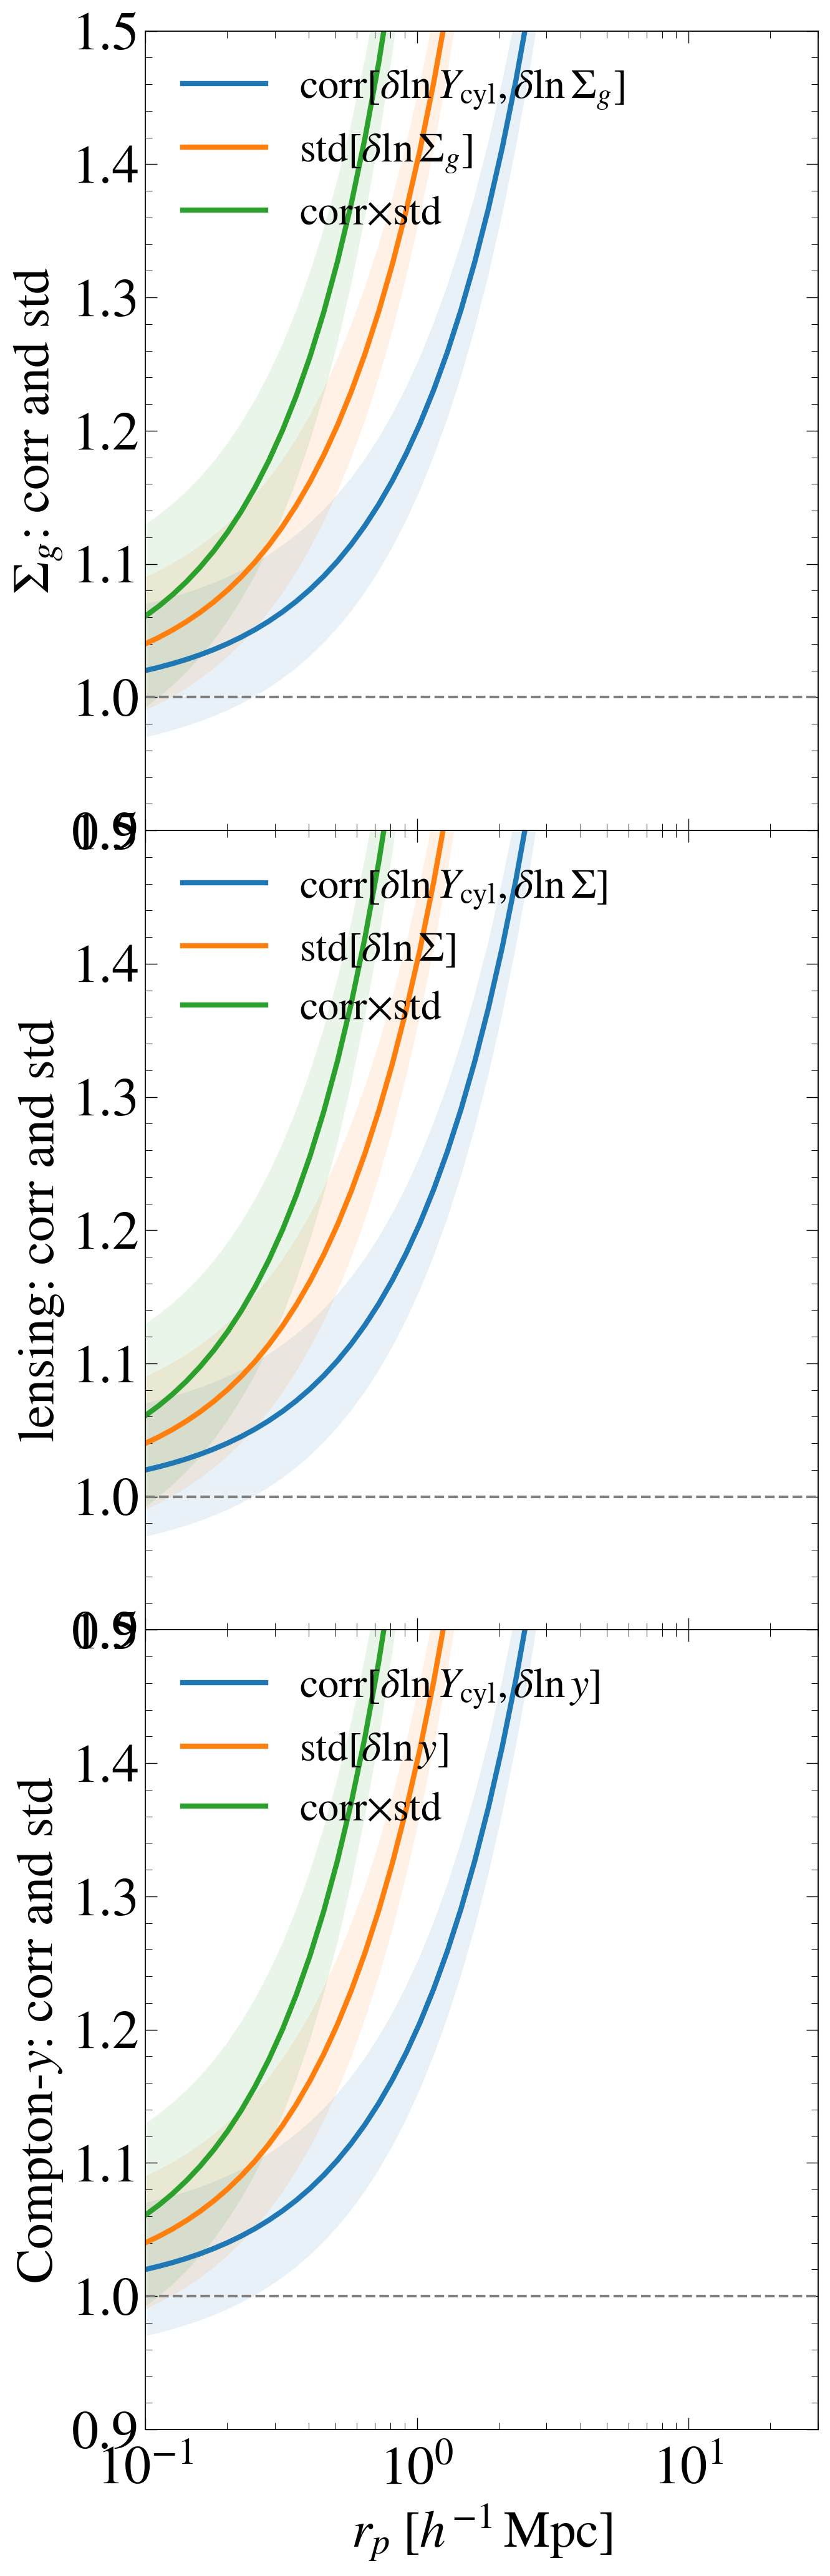

In [6]:
# using Ycyl (no noise) only
### use all the halos you have, without binning

fig, axes = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(7, 21),
    gridspec_kw={'hspace': 0}
)

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]


for row, ylabel in enumerate(row_ylabels):
    axes[row].set_ylabel(ylabel)

for col in range(4):
    axes[2].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")



for row in range(3):


    ax = axes[row]
    if row == 0:  # galaxy distribution
        
        ### TODO: placeholder
        rp = np.geomspace(0.1, 30)
        corr = 0.2*rp+1 
        corr_err = 0.05
        scatt = 0.4*rp+1 
        scatt_err = 0.05

        corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta\ln\Sigma_g]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma_g]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        
    if row == 1:  # lensing
        ## TODO: same for lensing with d=300
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta\ln\Sigma]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    if row == 2:  # SZ            
        ## TODO: same for y with d=300 (no noise)
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln Y_{\rm cyl} , \delta\ln y]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln y]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    ax.axhline(1, c='gray', ls='--')
    ax.set_ylim(0.9, 1.5)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    
    ax.legend(loc=2)
    ax.grid(False)
plt.savefig('../plots/Y_correlation.pdf')